# 06 — Interpretation: SHAP, Calibration, Error Overlap, Subgroups  [R2-1, R2-7]
Feature importance, calibration residuals, error overlap, and subgroup metrics with bootstrap CIs.

In [1]:
import json, inspect, warnings, os, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (StandardScaler, RobustScaler, PowerTransformer, MinMaxScaler, QuantileTransformer)
from sklearn.metrics import (accuracy_score, matthews_corrcoef, roc_auc_score, recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from scipy import stats
from lightgbm import LGBMClassifier
os.makedirs("results", exist_ok=True)
RS = 42
TEAL,ROSE,ORANGE,SAND,RED,LAV,SLATE,INK = ('#4A90A4','#C4887D','#E67E22','#C4A882','#C0392B','#8E7CC3','#7A8B9A','#2C3E4F')
plt.rcParams.update({'font.family':'DejaVu Sans','axes.facecolor':'#FAFBFC','figure.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.color':'#E4E9F0',
    'axes.titleweight':'bold','axes.axisbelow':True,'savefig.dpi':200,'savefig.bbox':'tight'})
NAMES = ['Manual Expert','DeepSeek','Claude Sonnet 4.6','GPT-5.4','CAAFE']
SHORT = ['Manual','DeepSeek','Claude 4.6','GPT-5.4','CAAFE']
COLS  = [TEAL,ROSE,RED,ORANGE,LAV]
CONT  = ['AGE','ANNUALCONTRIBUTION','ANNUALCLAIMAMOUNT','UNITSTOTAL']
DATA  = "Final Prepared Dataset - Diabetes and Hypertension Data.xlsx"

def load_raw():
    df = pd.read_excel(DATA)
    n_raw = len(df); df = df.drop_duplicates().reset_index(drop=True); n_dup = n_raw - len(df)
    df["ADHERENCE"] = (df["ADHERENCE"]=="ADHERENT").astype(int)
    for c in df.columns:
        if df[c].dtype=="bool": df[c]=df[c].astype(int)
    return df, n_raw, n_dup

def load_and_split():
    df,_,_ = load_raw()
    y=df["ADHERENCE"]; X=df.drop(columns=["ADHERENCE"])
    return train_test_split(X,y,test_size=0.2,stratify=y,random_state=RS)

def _manual(Xp):
    Xp=Xp.copy()
    Xp["LOG_CLAIM"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]); Xp["LOG_UNITS"]=np.log1p(Xp["UNITSTOTAL"])
    Xp["LOG_CONTRIB"]=np.log1p(Xp["ANNUALCONTRIBUTION"])
    Xp["CLAIM_PER_UNIT"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]/(Xp["UNITSTOTAL"]+1))
    Xp["CLAIM_RATIO"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]/(Xp["ANNUALCONTRIBUTION"]+1))
    Xp["UNITS_PER_AGE"]=Xp["UNITSTOTAL"]/(Xp["AGE"]+1); return Xp

_NS={"np":np,"pd":pd,"StandardScaler":StandardScaler,"RobustScaler":RobustScaler,
     "PowerTransformer":PowerTransformer,"MinMaxScaler":MinMaxScaler,"QuantileTransformer":QuantileTransformer}
def _load(p):
    ns=dict(_NS); exec(open(p,encoding="utf-8").read(),ns); return ns["preprocess"]
FROZEN={"DeepSeek":_load("llm_raw/DeepSeek_preprocess.py"),
        "Claude Sonnet 4.6":_load("llm_raw/Claude_Sonnet_4.6_preprocess.py"),
        "GPT-5.4":_load("llm_raw/GPT-5.4_preprocess.py")}
def _caafe(frame):
    ns={"df":frame.copy(),"np":np,"pd":pd}; exec(open("llm_raw/CAAFE_code.py",encoding="utf-8").read(),ns)
    return ns["df"].select_dtypes(include=[np.number]).fillna(0)
def transform_pair(name,x_fit,x_eval):
    if name=="Manual Expert": return _manual(x_fit),_manual(x_eval)
    if name=="CAAFE":
        tr=_caafe(x_fit); te=_caafe(x_eval).reindex(columns=tr.columns,fill_value=0); return tr,te
    tr,te=FROZEN[name](x_fit.copy(),x_eval.copy())
    if not isinstance(tr,pd.DataFrame):
        cols=(list(x_fit.columns)+["CONTRIBUTION_CLAIM_RATIO","UNITS_PER_CLAIM"]) if (name=="DeepSeek" and tr.shape[1]==x_fit.shape[1]+2) else [f"f{i}" for i in range(tr.shape[1])]
        tr=pd.DataFrame(tr,index=x_fit.index,columns=cols)
    if not isinstance(te,pd.DataFrame): te=pd.DataFrame(te,index=x_eval.index,columns=tr.columns)
    return tr,te.reindex(columns=tr.columns,fill_value=0)
def san(df): return pd.DataFrame(df).replace([np.inf,-np.inf],np.nan).fillna(0.0)
def nb_se(d,k=10):
    d=np.asarray(d); n=d.size; return np.sqrt(d.var(ddof=1)*(1.0/n+(1.0/k)/(1-1.0/k)))
def tost90(d,k=10):
    d=np.asarray(d); m=d.mean(); se=nb_se(d,k); c=stats.t.ppf(0.95,d.size-1); return m,se,[m-c*se,m+c*se]
def cv_metrics(name,X,y,drop_units=False,k=10,repeats=1):
    accs,mccs,aucs=[],[],[]
    for r in range(repeats):
        for tr,va in StratifiedKFold(k,shuffle=True,random_state=(RS if repeats==1 else 2026+r)).split(X,y):
            ftr,fva=transform_pair(name,X.iloc[tr],X.iloc[va])
            if drop_units:
                uc=[c for c in ftr.columns if 'UNIT' in c.upper()]
                ftr=ftr.drop(columns=uc); fva=fva.drop(columns=[c for c in uc if c in fva.columns])
            ftr,fva=san(ftr),san(fva)
            m=LGBMClassifier(random_state=RS,verbose=-1,n_jobs=1).fit(ftr,y.iloc[tr])
            p=m.predict(fva); pr=m.predict_proba(fva)[:,1]
            accs.append(accuracy_score(y.iloc[va],p)); mccs.append(matthews_corrcoef(y.iloc[va],p)); aucs.append(roc_auc_score(y.iloc[va],pr))
    return np.array(accs),np.array(mccs),np.array(aucs)
x_tr,x_ho,y_tr,y_ho = load_and_split()
print("Setup complete |", f"{len(x_tr)+len(x_ho):,} records, {x_tr.shape[1]} predictors")

Setup complete | 24,071 records, 11 predictors


### SHAP feature importance (Manual Expert)

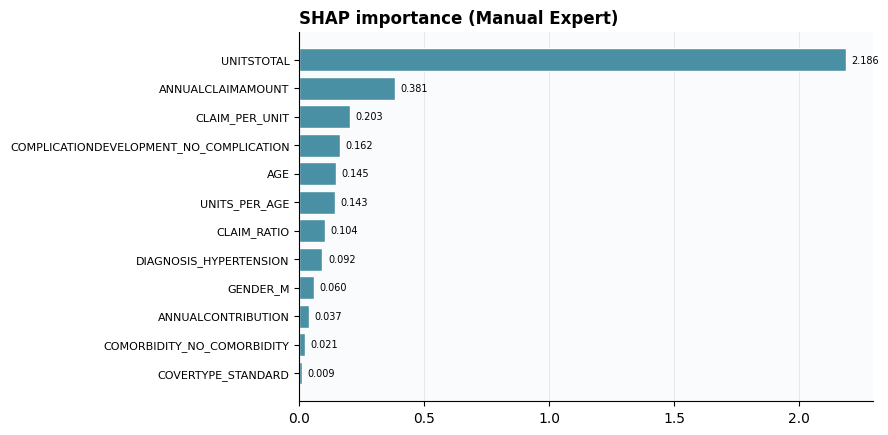

In [2]:
import shap
tr,ho=transform_pair('Manual Expert',x_tr,x_ho); tr,ho=san(tr),san(ho)
m=LGBMClassifier(random_state=RS,verbose=-1,n_jobs=1).fit(tr,y_tr)
sv=shap.TreeExplainer(m).shap_values(ho); sv=sv[1] if isinstance(sv,list) else sv
imp=pd.Series(np.abs(sv).mean(0),index=tr.columns).sort_values(ascending=False)
imp.to_frame('mean_abs_SHAP').to_excel('results/06_shap_importance.xlsx')
top=imp.sort_values().tail(12)
fig,ax=plt.subplots(figsize=(7.4,4.8)); ax.barh(range(len(top)),top.values,color=TEAL,edgecolor='white')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index,fontsize=8)
for i,v in enumerate(top.values): ax.text(v+top.max()*.01,i,f'{v:.3f}',va='center',fontsize=7)
ax.set_title('SHAP importance (Manual Expert)',loc='left'); ax.grid(axis='y',alpha=0)
plt.savefig('results/06_shap.png'); plt.show()

### Calibration (Brier, ECE) and residuals

,Pipeline,Brier,ECE
0,Manual Expert,0.1210,0.0094
1,DeepSeek,0.1196,0.0153
2,Claude Sonnet 4.6,0.1214,0.0099
3,GPT-5.4,0.1195,0.0136
4,CAAFE,0.1216,0.0119


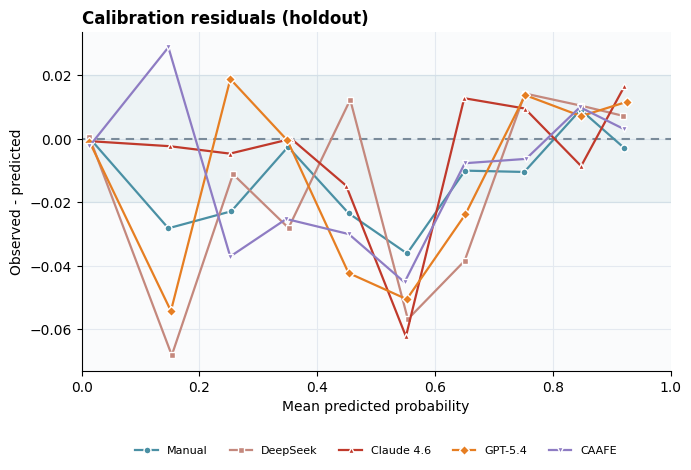

In [3]:
def ece(y,p,b=10):
    e=np.linspace(0,1,b+1); v=0
    for i in range(b):
        m=(p>e[i])&(p<=e[i+1])
        if m.any(): v+=m.mean()*abs(y[m].mean()-p[m].mean())
    return v
rows=[]; fig,ax=plt.subplots(figsize=(7.6,4.4)); ax.axhspan(-.02,.02,color=TEAL,alpha=.07); ax.axhline(0,ls=(0,(4,3)),color=SLATE)
for n,c,mk in zip(NAMES,COLS,['o','s','^','D','v']):
    t,h=transform_pair(n,x_tr,x_ho); mm=LGBMClassifier(random_state=RS,verbose=-1,n_jobs=1).fit(san(t),y_tr); pr=mm.predict_proba(san(h))[:,1]
    rows.append([n,round(brier_score_loss(y_ho,pr),4),round(ece(y_ho.values,pr),4)])
    fr,mp=calibration_curve(y_ho,pr,n_bins=10); ax.plot(mp,fr-mp,marker=mk,color=c,lw=1.6,label=SHORT[NAMES.index(n)],markeredgecolor='white',markersize=5)
cal=pd.DataFrame(rows,columns=['Pipeline','Brier','ECE']); display(cal); cal.to_excel('results/06_calibration.xlsx',index=False)
ax.set_xlim(0,1); ax.legend(ncol=5,frameon=False,fontsize=8,loc='lower center',bbox_to_anchor=(.5,-.28))
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed - predicted'); ax.set_title('Calibration residuals (holdout)',loc='left')
plt.savefig('results/06_calibration.png'); plt.show()

### Error overlap

,# pipelines misclassifying,Holdout samples,%
0,0,3740,77.7
1,1,118,2.5
2,2,93,1.9
3,3,87,1.8
4,4,111,2.3
5,5,666,13.8


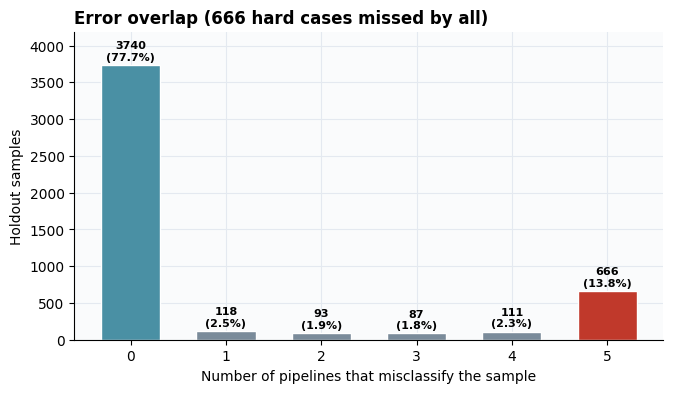

In [4]:
preds={}
for n in NAMES:
    t,h=transform_pair(n,x_tr,x_ho); mm=LGBMClassifier(random_state=RS,verbose=-1,n_jobs=1).fit(san(t),y_tr); preds[n]=(mm.predict(san(h))!=y_ho.values).astype(int)
nw=np.sum([preds[n] for n in NAMES],axis=0); dist=[int((nw==k).sum()) for k in range(6)]
eo=pd.DataFrame({'# pipelines misclassifying':list(range(6)),'Holdout samples':dist,'%':[round(d/len(y_ho)*100,1) for d in dist]})
display(eo); eo.to_excel('results/06_error_overlap.xlsx',index=False)
fig,ax=plt.subplots(figsize=(7.6,4.0)); ax.bar(range(6),dist,.62,color=[TEAL,SLATE,SLATE,SLATE,SLATE,RED],edgecolor='white')
for k,c in enumerate(dist): ax.text(k,c+max(dist)*.01,f'{c}\n({c/len(y_ho)*100:.1f}%)',ha='center',va='bottom',fontsize=8,fontweight='bold')
ax.set_xlabel('Number of pipelines that misclassify the sample'); ax.set_ylabel('Holdout samples'); ax.set_ylim(0,max(dist)*1.12)
ax.set_title(f'Error overlap ({dist[-1]} hard cases missed by all)',loc='left'); plt.savefig('results/06_error_overlap.png'); plt.show()

### [R2-7] Subgroup performance with bootstrap 95% CI

In [5]:
tr,ho=transform_pair('Manual Expert',x_tr,x_ho); m=LGBMClassifier(random_state=RS,verbose=-1,n_jobs=1).fit(san(tr),y_tr); pred=m.predict(san(ho))
rng=np.random.default_rng(RS)
def sub(mask):
    yy,pp=y_ho.values[mask],pred[mask]
    if mask.sum()<10 or len(np.unique(yy))<2: return None
    accs=[accuracy_score(yy[idx],pp[idx]) for idx in (rng.integers(0,len(yy),len(yy)) for _ in range(2000))]
    return [int(mask.sum()),round(accuracy_score(yy,pp),3),f"[{np.percentile(accs,2.5):.3f}, {np.percentile(accs,97.5):.3f}]",round(recall_score(yy,pp,pos_label=1),3),round(recall_score(yy,pp,pos_label=0),3),round(matthews_corrcoef(yy,pp),3)]
SGdef={'Complication':x_ho['COMPLICATIONDEVELOPMENT_NO_COMPLICATION'].values==0,'No complication':x_ho['COMPLICATIONDEVELOPMENT_NO_COMPLICATION'].values==1,
 'Comorbidity':x_ho['COMORBIDITY_NO_COMORBIDITY'].values==0,'No comorbidity':x_ho['COMORBIDITY_NO_COMORBIDITY'].values==1,
 'Hypertension':x_ho['DIAGNOSIS_HYPERTENSION'].values==1,'Diabetes':x_ho['DIAGNOSIS_HYPERTENSION'].values==0,
 'Male':x_ho['GENDER_M'].values==1,'Female':x_ho['GENDER_M'].values==0}
rows=[[k]+sub(v) for k,v in SGdef.items() if sub(v)]
sgt=pd.DataFrame(rows,columns=['Subgroup','n','Accuracy','95% CI','Sens','Spec','MCC']); display(sgt); sgt.to_excel('results/06_subgroup_ci.xlsx',index=False)
print('\nAll results saved under results/  (Excel + PNG).')

,Subgroup,n,Accuracy,95% CI,Sens,Spec,MCC
0,Complication,454,0.714,"[0.667, 0.756]",0.784,0.656,0.440
1,No complication,4361,0.831,"[0.820, 0.842]",0.876,0.801,0.664
2,Comorbidity,1380,0.792,"[0.771, 0.814]",0.890,0.696,0.597
3,No comorbidity,3435,0.831,"[0.818, 0.843]",0.854,0.818,0.654
4,Hypertension,3886,0.827,"[0.815, 0.839]",0.870,0.799,0.655
5,Diabetes,929,0.791,"[0.764, 0.817]",0.855,0.739,0.592
6,Male,2557,0.826,"[0.811, 0.839]",0.878,0.793,0.655
7,Female,2258,0.814,"[0.798, 0.830]",0.855,0.784,0.630



All results saved under results/  (Excel + PNG).
